# 主題: Spiral - Different Epochs
做漩渦造型的2D數據

In [1]:
import numpy as np
import torch

# ============================================================
# 2D OU Dataset with spiral target
# x0 follows a noisy spiral
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim = 2

beta = 1.0
sigma = np.sqrt(2.0)

T = 5.0
eps_t = 1e-3
N = 10000

# ============================================================
# Spiral x0
# ============================================================

theta = np.random.uniform(0.0, 4.0 * np.pi, N).astype(np.float32)

r = 0.45 * theta

x0_np = np.stack(
    [
        r * np.cos(theta),
        r * np.sin(theta)
    ],
    axis=1
).astype(np.float32)

# add noise thickness
x0_np = x0_np + 0.25 * np.random.randn(N, dim).astype(np.float32)

# shift spiral center to (10,10)
mu_shift_np = np.array([10.0, 10.0], dtype=np.float32)
x0_np = x0_np + mu_shift_np

# ============================================================
# Random t
# ============================================================

t_np = np.random.uniform(
    eps_t,
    T,
    N
).astype(np.float32)

t_col = t_np.reshape(-1, 1)

a_t_np = np.exp(-beta * t_col).astype(np.float32)

cond_var_t_np = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * t_col))
).astype(np.float32)

cond_std_t_np = np.sqrt(cond_var_t_np).astype(np.float32)

# ============================================================
# Forward OU: xt | x0
# ============================================================

eps_np = np.random.randn(N, dim).astype(np.float32)

xt_np = (
    a_t_np * x0_np
    + cond_std_t_np * eps_np
).astype(np.float32)

# ============================================================
# Conditional score only
# ∇ log p(xt | x0)
# ============================================================

cond_score_np = (
    -(xt_np - a_t_np * x0_np)
    / cond_var_t_np
).astype(np.float32)

# No exact marginal score for spiral
score_t_np = np.zeros_like(cond_score_np).astype(np.float32)

# ============================================================
# Torch tensors
# ============================================================

mu_shift = torch.tensor(mu_shift_np, device=device)

x0_train = torch.tensor(x0_np, device=device)
xt_train = torch.tensor(xt_np, device=device)
t_train = torch.tensor(t_np, device=device).view(-1, 1)

cond_score_train = torch.tensor(cond_score_np, device=device)

print("x0 mean:", x0_np.mean(axis=0))
print("x0 cov:")
print(np.cov(x0_np.T))

print("xt mean:", xt_np.mean(axis=0))
print("xt cov:")
print(np.cov(xt_np.T))

print("x0_train shape:", x0_train.shape)
print("xt_train shape:", xt_train.shape)
print("t_train shape:", t_train.shape)
print("cond_score_train shape:", cond_score_train.shape)

x0 mean: [10.042723  9.551461]
x0 cov:
[[ 5.43264992 -0.63149802]
 [-0.63149802  5.12173405]]
xt mean: [1.9835013 1.8915526]
xt cov:
[[7.53147873 5.78774841]
 [5.78774841 6.99738197]]
x0_train shape: torch.Size([10000, 2])
xt_train shape: torch.Size([10000, 2])
t_train shape: torch.Size([10000, 1])
cond_score_train shape: torch.Size([10000, 2])


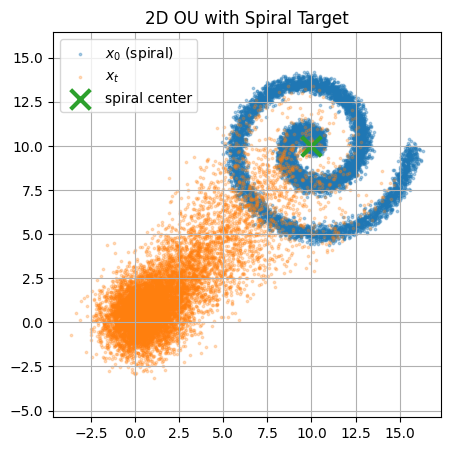

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.scatter(
    x0_np[:,0],
    x0_np[:,1],
    s=3,
    alpha=0.35,
    label=r"$x_0$ (spiral)"
)

plt.scatter(
    xt_np[:,0],
    xt_np[:,1],
    s=3,
    alpha=0.25,
    label=r"$x_t$"
)

plt.scatter(
    10,
    10,
    marker="x",
    s=200,
    linewidths=3,
    label="spiral center"
)

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.title("2D OU with Spiral Target")

plt.show()

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.SiLU(),

            nn.Linear(128, 128),
            nn.SiLU(),

            nn.Linear(128, 128),
            nn.SiLU(),

            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ScoreNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

x0_train = x0_train.to(device)
xt_train = xt_train.to(device)
t_train = t_train.to(device)
cond_score_train = cond_score_train.to(device)

# Spiral Training

In [5]:
import copy

T = 5.0
eps_t = 0.05

epochs = 1000
batch_size = 2048

save_epochs = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
saved_models = {}

L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(1, epochs + 1):

    idx = torch.randint(
        0,
        x0_train.shape[0],
        (batch_size,),
        device=device
    )

    x0 = x0_train[idx]

    t_batch = (
        eps_t
        + (T - eps_t)
        * torch.rand(batch_size, 1, device=device)
    )

    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    pred_score = model(xt, t_batch)

    L_DSM = (
        (pred_score - cond_score) ** 2
    ).sum(dim=1).mean()

    div_score = 0

    for j in range(dim):
        grad_j = torch.autograd.grad(
            outputs=pred_score[:, j].sum(),
            inputs=xt,
            create_graph=True,
            retain_graph=True
        )[0][:, j]

        div_score = div_score + grad_j

    L_ISM = (
        (pred_score ** 2).sum(dim=1)
        + 2 * div_score
    ).mean()

    I_DSM = (
        (pred_score ** 2).sum(dim=1)
        - (pred_score * cond_score).sum(dim=1)
    ).mean()

    loss = L_DSM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    L_DSM_history.append(L_DSM.item())
    L_ISM_history.append(L_ISM.item())
    I_DSM_history.append(I_DSM.item())

    if epoch in save_epochs:
        saved_models[epoch] = copy.deepcopy(model.state_dict())

    if epoch in save_epochs:
        print(
            f"Epoch {epoch:4d} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch  100 | L_DSM = 0.87123209 | L_ISM = -1.57531071 | I_DSM = -0.04259642
Epoch  200 | L_DSM = 0.81632394 | L_ISM = -1.66088319 | I_DSM = -0.01226963
Epoch  300 | L_DSM = 0.83726978 | L_ISM = -1.68366194 | I_DSM = 0.01179519
Epoch  400 | L_DSM = 0.81442428 | L_ISM = -1.64189851 | I_DSM = -0.00839831
Epoch  500 | L_DSM = 0.77215427 | L_ISM = -1.66153371 | I_DSM = -0.02189020
Epoch  600 | L_DSM = 0.83760309 | L_ISM = -1.64820969 | I_DSM = -0.03432911
Epoch  700 | L_DSM = 0.82621616 | L_ISM = -1.65076363 | I_DSM = -0.01660890
Epoch  800 | L_DSM = 0.75390375 | L_ISM = -1.74664521 | I_DSM = 0.00518841
Epoch  900 | L_DSM = 0.89121020 | L_ISM = -1.73824632 | I_DSM = 0.00346238
Epoch 1000 | L_DSM = 0.78393680 | L_ISM = -1.68010211 | I_DSM = -0.03318893


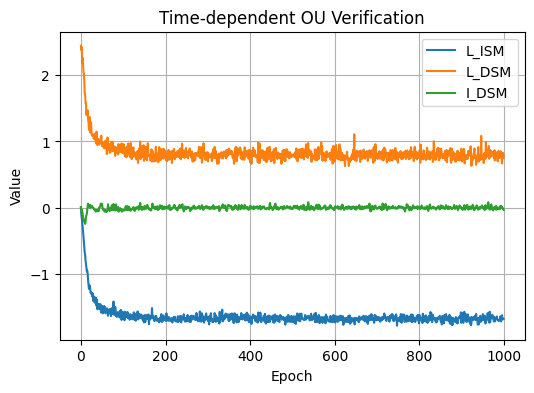

In [6]:
plt.figure(figsize=(6,4))

#plt.plot(L_ESM_history, label='L_ESM')
### Spiral的marginal score \nabla log p_t(x) 沒有ESM解析式

plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

# Spiral Reverse

In [12]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

T = 5.0
beta = 1.0
sigma = np.sqrt(2.0)

dim = 2

num_samples = 10000
num_eval = 10000
steps = 5000
dt = T / steps

epoch_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


def ou_cond_var(t):
    return (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * t))
    )


def compute_losses_spiral(model, x0_eval, t_now):

    x0_eval = x0_eval.clone().detach()

    a_t = np.exp(-beta * t_now)
    cond_var_t = ou_cond_var(t_now)
    cond_std_t = np.sqrt(cond_var_t)

    xt_eval = (
        a_t * x0_eval
        + cond_std_t * torch.randn_like(x0_eval)
    )

    xt_eval = xt_eval.clone().detach().requires_grad_(True)

    t_tensor = torch.ones(xt_eval.shape[0], 1, device=device) * t_now

    cond_score = (
        -(xt_eval - a_t * x0_eval)
        / cond_var_t
    )

    pred_score = model(xt_eval, t_tensor)

    L_DSM = (
        (pred_score - cond_score) ** 2
    ).sum(dim=1).mean()

    div_score = 0

    for j in range(dim):
        grad_j = torch.autograd.grad(
            outputs=pred_score[:, j].sum(),
            inputs=xt_eval,
            create_graph=False,
            retain_graph=True
        )[0][:, j]

        div_score = div_score + grad_j

    L_ISM = (
        (pred_score ** 2).sum(dim=1)
        + 2 * div_score
    ).mean()

    I_DSM = (
        (pred_score ** 2).sum(dim=1)
        - (pred_score * cond_score).sum(dim=1)
    ).mean()

    return {
        "L_DSM": L_DSM.item(),
        "L_ISM": L_ISM.item(),
        "I_DSM": I_DSM.item(),
    }


# fixed evaluation x0 from spiral dataset
idx_eval = torch.randint(
    0,
    x0_train.shape[0],
    (num_eval,),
    device=device
)

x0_eval_for_loss = x0_train[idx_eval]

In [13]:
# ============================================================
# Fixed evaluation time for indicators
# ============================================================

t_eval_for_loss = 1e-3

idx_eval = torch.randint(
    0,
    x0_train.shape[0],
    (num_eval,),
    device=device
)

x0_eval_for_loss = x0_train[idx_eval]

In [17]:
# ============================================================
# Spiral Reverse sampling + indicators for each epoch
# ============================================================

sample_dict = {}
reverse_results = []
indicator_results = []

target_mean = x0_np.mean(axis=0)
target_cov = np.cov(x0_np.T)

for epoch in epoch_list:

    model.load_state_dict(saved_models[epoch])
    model.eval()

    # indicators: DSM / ISM / I_DSM only
    losses = compute_losses_spiral(
        model,
        x0_eval_for_loss,
        t_eval_for_loss
    )

    indicator_results.append({
        "epoch": epoch,
        **losses
    })

    # --------------------------------------------------------
    # Start from empirical p_T:
    # sample x0 from spiral, then forward to x_T
    # --------------------------------------------------------

    idx = torch.randint(
        0,
        x0_train.shape[0],
        (num_samples,),
        device=device
    )

    x0_start = x0_train[idx]

    a_T = np.exp(-beta * T)

    cond_var_T = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * T))
    )

    cond_std_T = np.sqrt(cond_var_T)

    x = (
        a_T * x0_start
        + cond_std_T * torch.randn_like(x0_start)
    )

    # --------------------------------------------------------
    # Reverse SDE: x_T -> x_0
    # --------------------------------------------------------

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones(num_samples, 1, device=device) * t_now

            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt)
                #+ sigma * np.sqrt(dt) * noise
            #)

    samples_reverse = x.detach().cpu().numpy()
    sample_dict[epoch] = samples_reverse

    reverse_mean = samples_reverse.mean(axis=0)
    reverse_cov = np.cov(samples_reverse.T)

    reverse_results.append({
        "epoch": epoch,

        "mean_x1": reverse_mean[0],
        "mean_x2": reverse_mean[1],

        "mean_error_norm": np.linalg.norm(reverse_mean - target_mean),
        "cov_error": np.linalg.norm(reverse_cov - target_cov),
    })


df_reverse = pd.DataFrame(reverse_results)
df_indicators = pd.DataFrame(indicator_results)

df_summary = pd.merge(
    df_reverse,
    df_indicators,
    on="epoch",
    how="inner"
)

display(df_summary)


# ============================================================
# Plot spiral target and reverse samples side by side
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, epoch in zip(axes, epoch_list):

    samples = sample_dict[epoch]
    row = df_summary[df_summary["epoch"] == epoch].iloc[0]

    ax.scatter(
        x0_np[:, 0],
        x0_np[:, 1],
        s=2,
        alpha=0.12,
        label="target spiral"
    )

    ax.scatter(
        samples[:, 0],
        samples[:, 1],
        s=3,
        alpha=0.25,
        label=f"reverse epoch={epoch}"
    )

    ax.set_title(
        f"Epoch {epoch}\n"
        f"mean=({row['mean_x1']:.2f},{row['mean_x2']:.2f})"
    )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

    ax.set_xlim(2, 18)
    ax.set_ylim(2, 18)
    ax.set_aspect("equal", adjustable="box")

    ax.grid(True)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

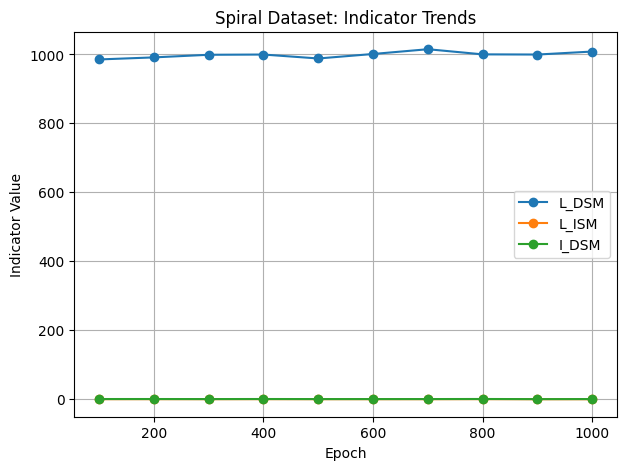

In [ ]:
import pandas as pd
plt.figure(figsize=(7, 5))

plt.plot(
    df_summary["epoch"],
    df_summary["L_DSM"],
    marker="o",
    label="L_DSM"
)

plt.plot(
    df_summary["epoch"],
    df_summary["L_ISM"],
    marker="o",
    label="L_ISM"
)

plt.plot(
    df_summary["epoch"],
    df_summary["I_DSM"],
    marker="o",
    label="I_DSM"
)

plt.xlabel("Epoch")
plt.ylabel("Indicator Value")
plt.title("Spiral Dataset: Indicator Trends")

plt.grid(True)
plt.legend()

plt.show()

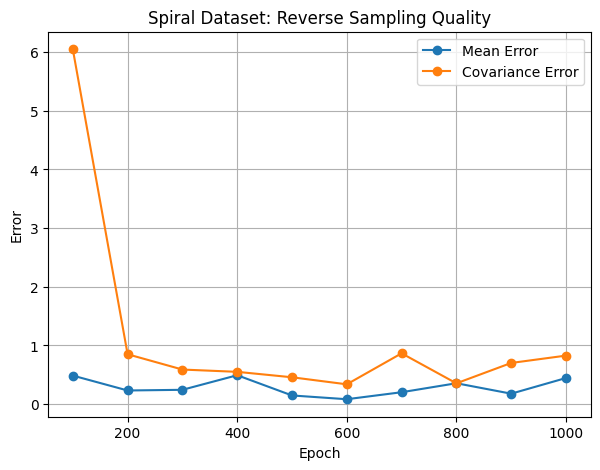

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    df_summary["epoch"],
    df_summary["mean_error_norm"],
    marker="o",
    label="Mean Error"
)

plt.plot(
    df_summary["epoch"],
    df_summary["cov_error"],
    marker="o",
    label="Covariance Error"
)

plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Spiral Dataset: Reverse Sampling Quality")

plt.grid(True)
plt.legend()

plt.show()

# 最底